In [1]:
import numpy as np 
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath("/Users/vashqu/Desktop/Assignment-2/src"))
import src
import seaborn as sns
from sklearn.decomposition import PCA


# Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the breast cancer dataset to understand feature distributions, detect class imbalances, check for missing values, decide on how to deal with them and clean the dataset and assess overall data before proceeding to building the models.


In [3]:
df = pd.read_csv('/Users/vashqu/Desktop/Assignment-2/data/breast_cancer.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,M,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,...,19.07,30.88,123.40,1138.0,0.1464,0.1871,0.29140,0.16090,0.3029,0.08216
1,2,B,11.50,18.45,73.28,407.4,0.09345,0.05991,0.02638,0.02069,...,12.97,22.46,83.12,508.9,0.1183,0.1049,0.08105,0.06544,0.2740,NaN
2,3,M,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,...,16.84,27.66,112.00,876.5,0.1131,0.1924,0.23220,0.11190,0.2809,0.06287
3,4,M,18.82,21.97,123.70,1110.0,0.10180,0.13890,0.15940,0.08744,...,22.66,30.93,145.30,1603.0,0.1390,0.3463,0.39120,0.17080,0.3007,0.08314
4,5,B,12.95,16.02,83.14,513.7,0.10050,0.07943,0.06155,0.03370,...,13.74,19.93,88.81,585.4,0.1483,NaN,0.22410,0.10560,0.3380,0.09584


In [4]:
print(df.shape)
print(df.columns)


(512, 32)
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       512 non-null    int64  
 1   diagnosis                512 non-null    object 
 2   radius_mean              505 non-null    float64
 3   texture_mean             507 non-null    float64
 4   perimeter_mean           507 non-null    float64
 5   area_mean                508 non-null    float64
 6   smoothness_mean          506 non-null    float64
 7   compactness_mean         511 non-null    float64
 8   concavity_mean           502 non-null    float64
 9   concave points_mean      504 non-null    float64
 10  symmetry_mean            507 non-null    float64
 11  fractal_dimension_mean   509 non-null    float64
 12  radius_se                510 non-null    float64
 13  texture_se               505 non-null    float64
 14  perimeter_se             5

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,512.000000,505.00000,507.000000,507.000000,508.000000,506.000000,511.000000,502.000000,504.000000,507.000000,...,507.000000,510.000000,505.000000,505.000000,507.000000,503.000000,508.000000,501.000000,509.000000,505.000000
mean,256.500000,14.17355,19.364142,92.231933,657.616929,0.096168,0.103624,0.088031,0.048893,0.181339,...,16.313700,25.754941,107.876515,889.918812,0.131889,0.251145,0.272561,0.114208,0.289997,0.083879
std,147.945936,3.55379,4.314426,24.584304,357.110765,0.014208,0.053119,0.080220,0.039362,0.027501,...,4.885558,6.152356,34.106884,579.834235,0.023130,0.155159,0.209698,0.065945,0.061297,0.018044
min,1.000000,6.98100,9.710000,43.790000,143.500000,0.062510,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,128.750000,11.71000,16.195000,75.235000,420.175000,0.085843,0.064130,0.028835,0.019983,0.162100,...,12.980000,21.222500,84.160000,514.000000,0.114750,0.143700,0.116625,0.064130,0.250600,0.071470
50%,256.500000,13.40000,18.890000,86.340000,548.750000,0.095200,0.091820,0.059640,0.033455,0.179200,...,14.980000,25.445000,97.900000,686.600000,0.131100,0.211800,0.225450,0.099100,0.281800,0.079930
75%,384.250000,15.78000,21.830000,104.200000,784.150000,0.105250,0.129850,0.128650,0.073460,0.195700,...,19.125000,30.015000,127.100000,1124.000000,0.146000,0.328050,0.385300,0.161300,0.317600,0.092030
max,512.000000,28.11000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
df.isna().sum()

id                          0
diagnosis                   0
radius_mean                 7
texture_mean                5
perimeter_mean              5
area_mean                   4
smoothness_mean             6
compactness_mean            1
concavity_mean             10
concave points_mean         8
symmetry_mean               5
fractal_dimension_mean      3
radius_se                   2
texture_se                  7
perimeter_se                1
area_se                     3
smoothness_se               6
compactness_se              4
concavity_se                2
concave points_se           4
symmetry_se                 5
fractal_dimension_se        5
radius_worst                5
texture_worst               2
perimeter_worst             7
area_worst                  7
smoothness_worst            5
compactness_worst           9
concavity_worst             4
concave points_worst       11
symmetry_worst              3
fractal_dimension_worst     7
dtype: int64

In [8]:
print(df.duplicated().sum())

0


We loaded and inspected the dataset. We have missing values in all of our features and no duplicates. Our next step is to check the nature of the NaNs so we can decide on how to deal with them

<Axes: >

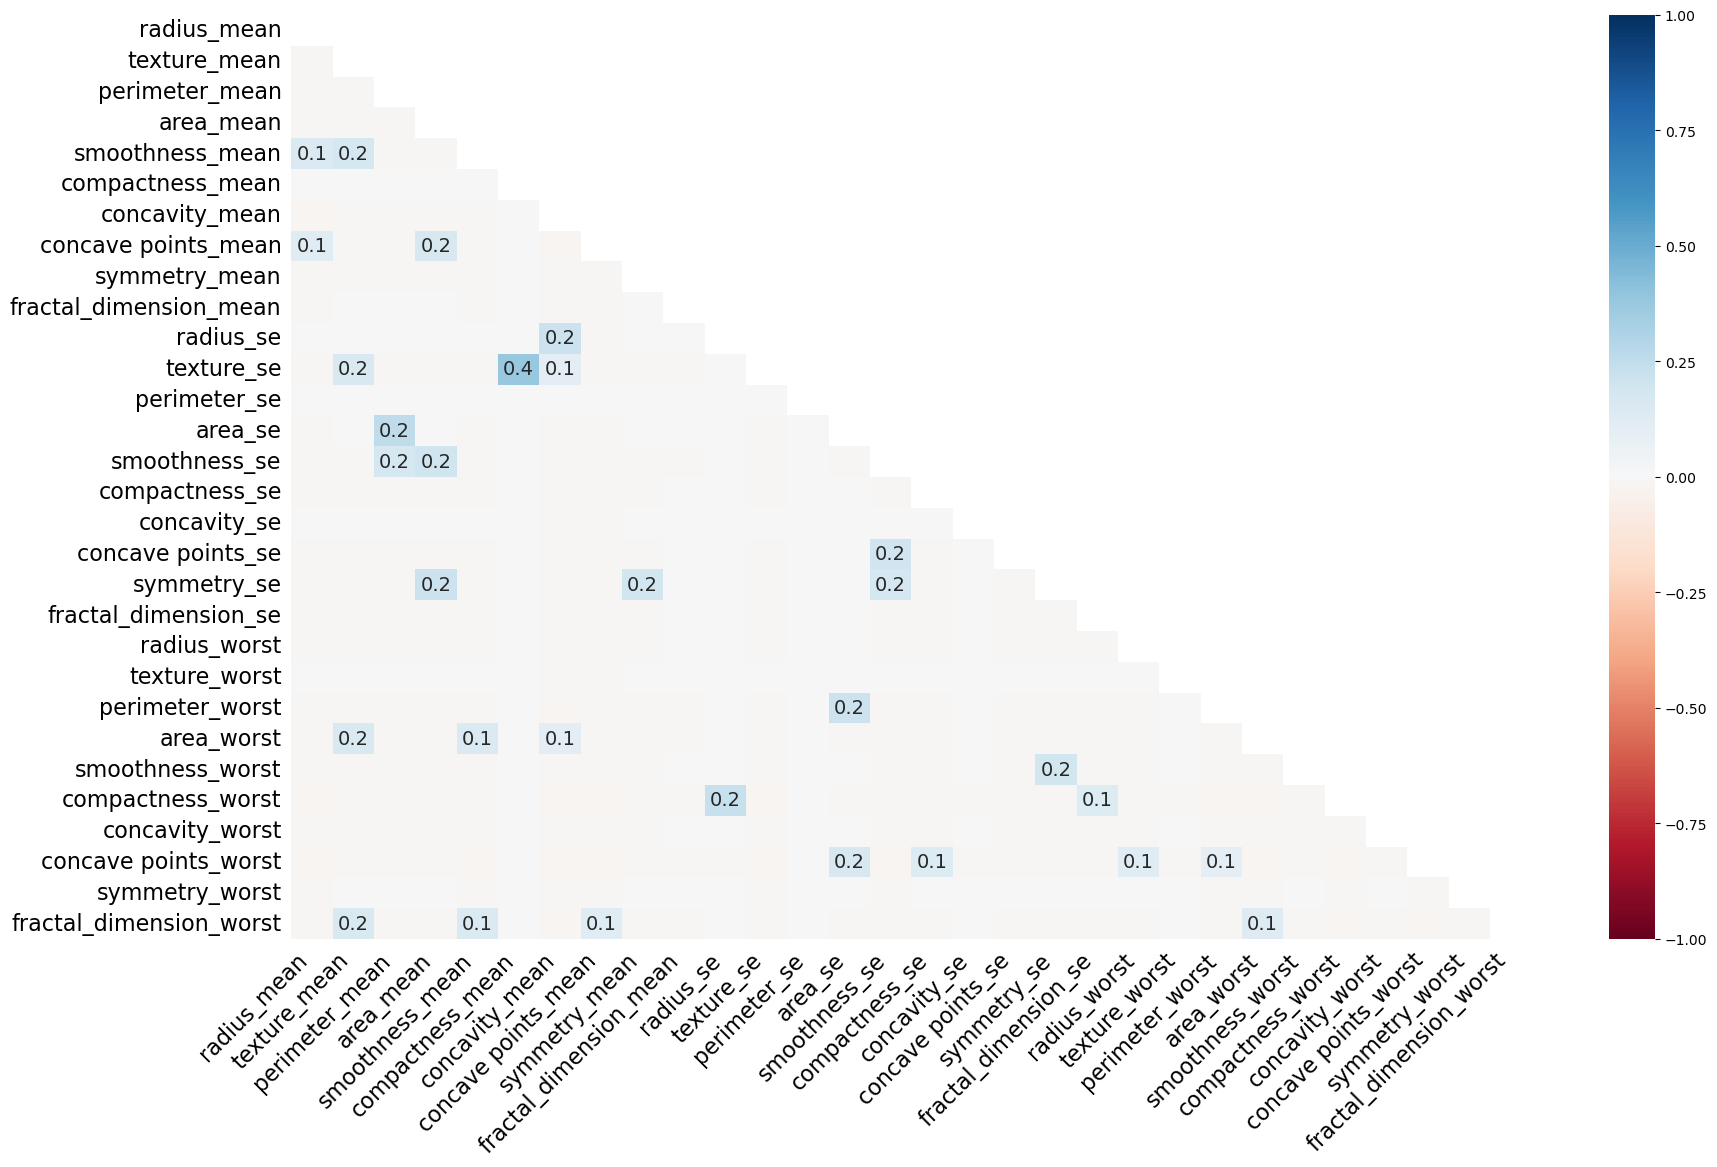

In [9]:
msno.heatmap(df)

## Feature Correlation Analysis and Imputation Strategy

To better understand relationships between features and to check for potential redundancy or collinearity, we plotted a correlation heatmap. Most correlations fall below 0.2, with very few reaching up to 0.4. This suggests that:

- There is limited linear dependency across features.
- There are no strong block structures or highly correlated feature groups.

This observation also helps interpret the nature of missingness. Since no strong dependencies are observed, we infer that missing values are likely **Missing Completely At Random (MCAR)** or only **Weakly Missing At Random (MAR)**.

We will use **median imputation** for handling missing values because:
- It is **robust to outliers** (unlike the mean).
- Imputation will be performed **inside the pipeline**, after the data is split, to **avoid data leakage** during cross-validation.




In [10]:
print("Class Distribution:")
print(df['diagnosis'].value_counts())
print("Class Distribution (Relative):")
print(df['diagnosis'].value_counts(normalize=True))

Class Distribution:
diagnosis
B    321
M    191
Name: count, dtype: int64
Class Distribution (Relative):
diagnosis
B    0.626953
M    0.373047
Name: proportion, dtype: float64


The class distribution is as follows:
- 321 benign samples (62.7%)
- 191 malignant samples (37.3%)

This class imbalance is moderate and should be addressed during model evaluation.

To properly evaluate classifier performance, we will:
- Use **balanced metrics** like MCC, F1 score, Balanced Accuracy, and AUC.
- Apply **stratified cross-validation** to preserve class ratios in all folds.


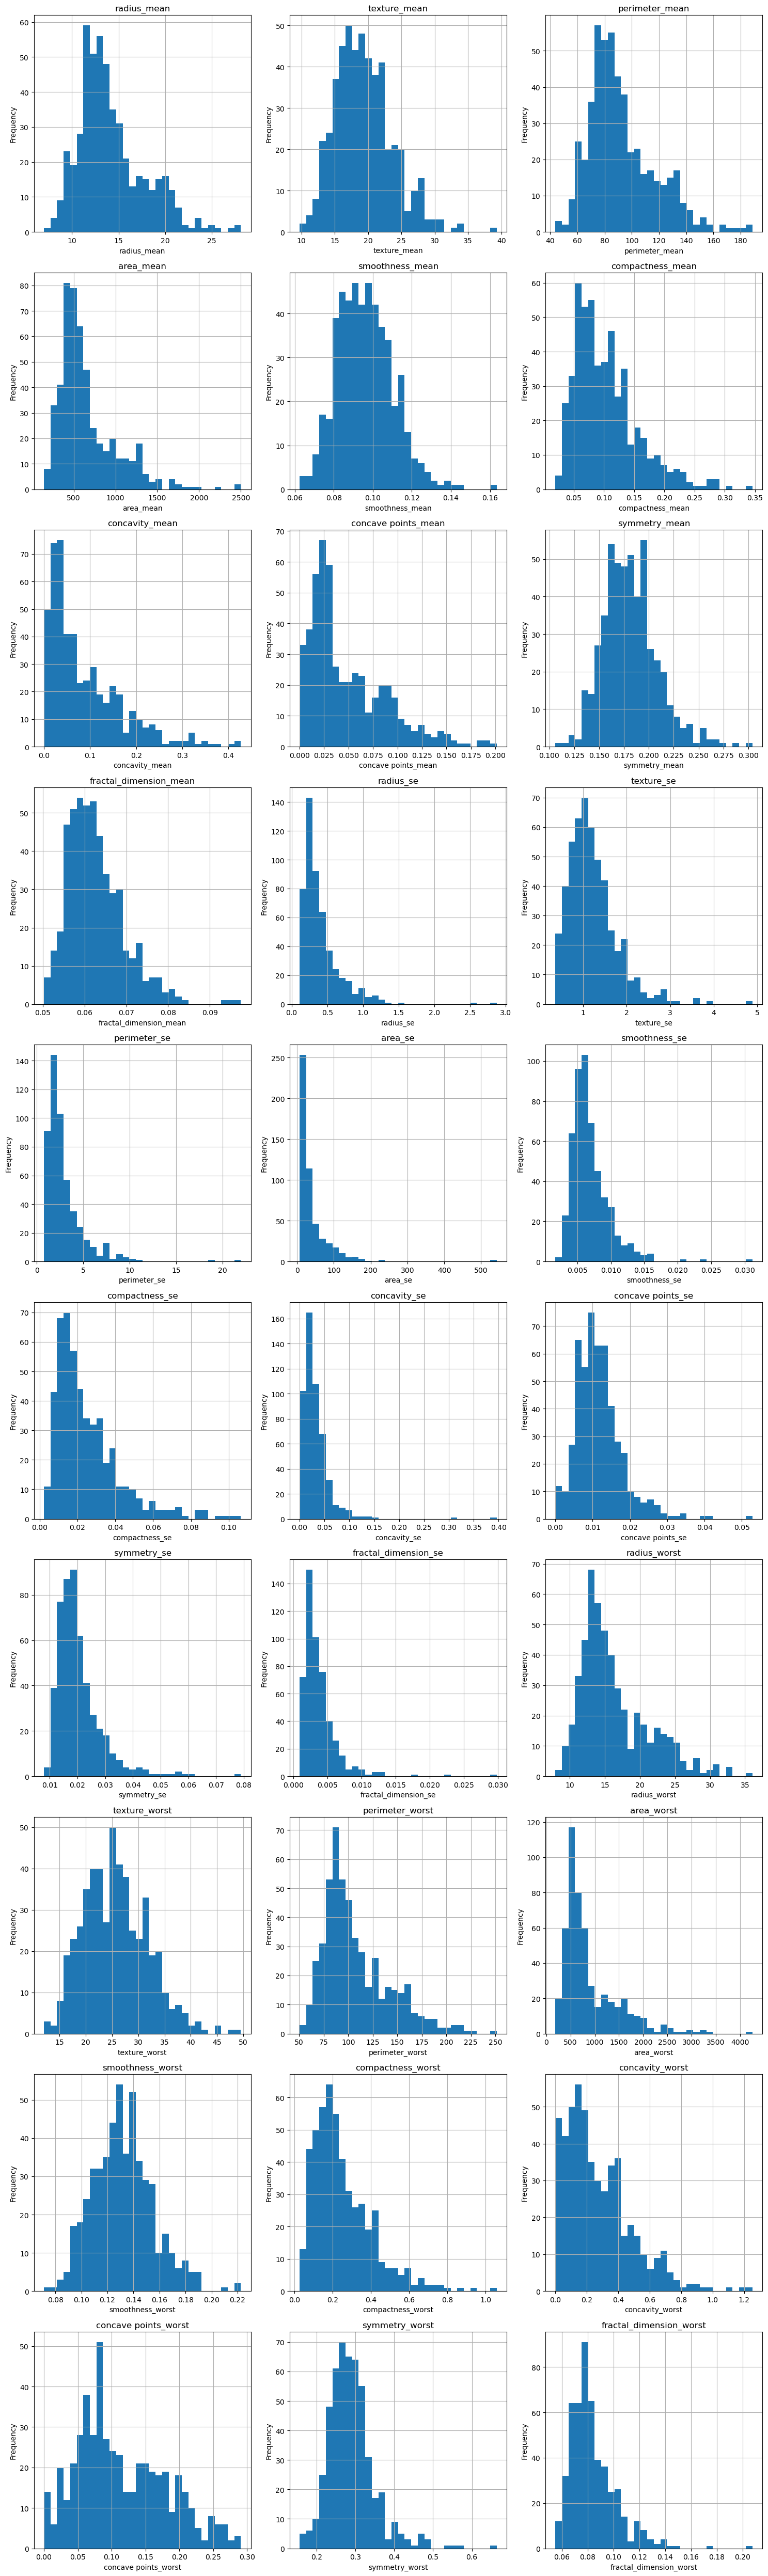

In [ ]:

cols = df.columns[2:] #skip id and diagnosis
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    df[col].hist(bins=30, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




We plotted histograms for all numerical features in the dataset. Most features are **right-skewed**, meaning they have long tails on the right. In some cases (e.g., `area_se`, `perimeter_se`, `concavity_se`), the skewness is strong, indicating the presence of outliers or long-tail effects.

### Implications for Preprocessing

- **Median Imputation**: Given the skewness, we have another good indication to use **median imputation** and not the mean as it is more robust to outliers.
- **Robust Scaling**: Instead of `StandardScaler` (which is sensitive to outliers), we will use **RobustScaler**, which uses the median and interquartile range (IQR) and is more appropriate for right-skewed data.
- **Pipeline Safety**: All transformations, including imputation and scaling, will be performed inside a **scikit-learn pipeline** to prevent data leakage during cross-validation.

We will now drop unecessary columns, save the cleaned csv and then apply preprocessing to visualise our preprocess results.

In [ ]:
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'B':0, 'M':1}) # encode diagnosis

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,...,19.07,30.88,123.40,1138.0,0.1464,0.1871,0.29140,0.16090,0.3029,0.08216
1,0,11.50,18.45,73.28,407.4,0.09345,0.05991,0.02638,0.02069,0.1834,...,12.97,22.46,83.12,508.9,0.1183,0.1049,0.08105,0.06544,0.2740,NaN
2,1,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,...,16.84,27.66,112.00,876.5,0.1131,0.1924,0.23220,0.11190,0.2809,0.06287
3,1,18.82,21.97,123.70,1110.0,0.10180,0.13890,0.15940,0.08744,0.1943,...,22.66,30.93,145.30,1603.0,0.1390,0.3463,0.39120,0.17080,0.3007,0.08314
4,0,12.95,16.02,83.14,513.7,0.10050,0.07943,0.06155,0.03370,0.1730,...,13.74,19.93,88.81,585.4,0.1483,NaN,0.22410,0.10560,0.3380,0.09584


In [13]:
df.to_csv('/Users/vashqu/Desktop/Assignment-2/data/breast_cancer_clean.csv', index=False)

In [14]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [16]:
prep = src.Preprocessor()
X_prep = prep.fit_transform(X)

print("X_prep shape:", X_prep.shape)
print("First 5 rows of X_prep:")
print(X_prep[:5])

X_prep shape: (512, 30)
First 5 rows of X_prep:
[[ 3.18012422e-01  2.21329763e-01  2.93629293e-01  3.74663631e-01
   1.81177392e-01 -3.02549229e-01  1.50830040e-01  3.81422236e-01
  -6.22826909e-01 -2.64394830e-01  5.71484147e-01  1.75316112e-01
   5.00967653e-01  7.50703331e-01 -1.91673747e-01 -4.44796619e-01
  -2.10013908e-01  2.89896062e-02 -5.98771419e-01 -4.45655729e-01
   6.81666667e-01  6.26332469e-01  6.02160694e-01  7.63693271e-01
   5.01228501e-01 -1.37815595e-01  2.47258412e-01  6.50697552e-01
   3.16697936e-01  1.11430356e-01]
 [-4.72049689e-01 -7.85363677e-02 -4.56523639e-01 -3.90119368e-01
  -9.13718836e-02 -4.87101206e-01 -3.50566535e-01 -2.54447601e-01
   1.26984127e-01 -2.50293772e-01  2.60260650e-01 -4.40772632e-01
   2.18413049e-01  8.24031219e-02  3.33050127e-02 -4.96038035e-01
  -5.09239022e-01 -2.41815739e-01  5.41868736e-01 -7.17758639e-01
  -3.35000000e-01 -3.43993086e-01 -3.49017061e-01 -3.00638667e-01
  -4.19328419e-01 -5.96456967e-01 -5.41381573e-01 -3.544090

In [17]:
print(np.isnan(X_prep).sum())



0


We applied a custom `Preprocessor` class that includes:

- **Median imputation** for missing values
- **RobustScaler** for feature scaling, which centers the data around the median and scales using the interquartile range (IQR), making it ideal for skewed distributions

After fitting and transforming the feature matrix `X`, we confirmed:

- The output matrix `X_prep` has shape `(512, 30)`
- No missing values remain after preprocessing
- The pipeline is modular and can be used in future training, validation, and deployment


The histograms below compare the distributions of features **before** and **after** scaling:

- Raw features are heavily skewed in many cases (especially `area_se`, `concavity_se`, `perimeter_se`)
- After applying `RobustScaler`, the features retain their shape but are transformed to a comparable scale — suitable for models that are sensitive to feature magnitudes (e.g., SVMs, logistic regression)

This ensures better convergence and performance stability across classifiers.


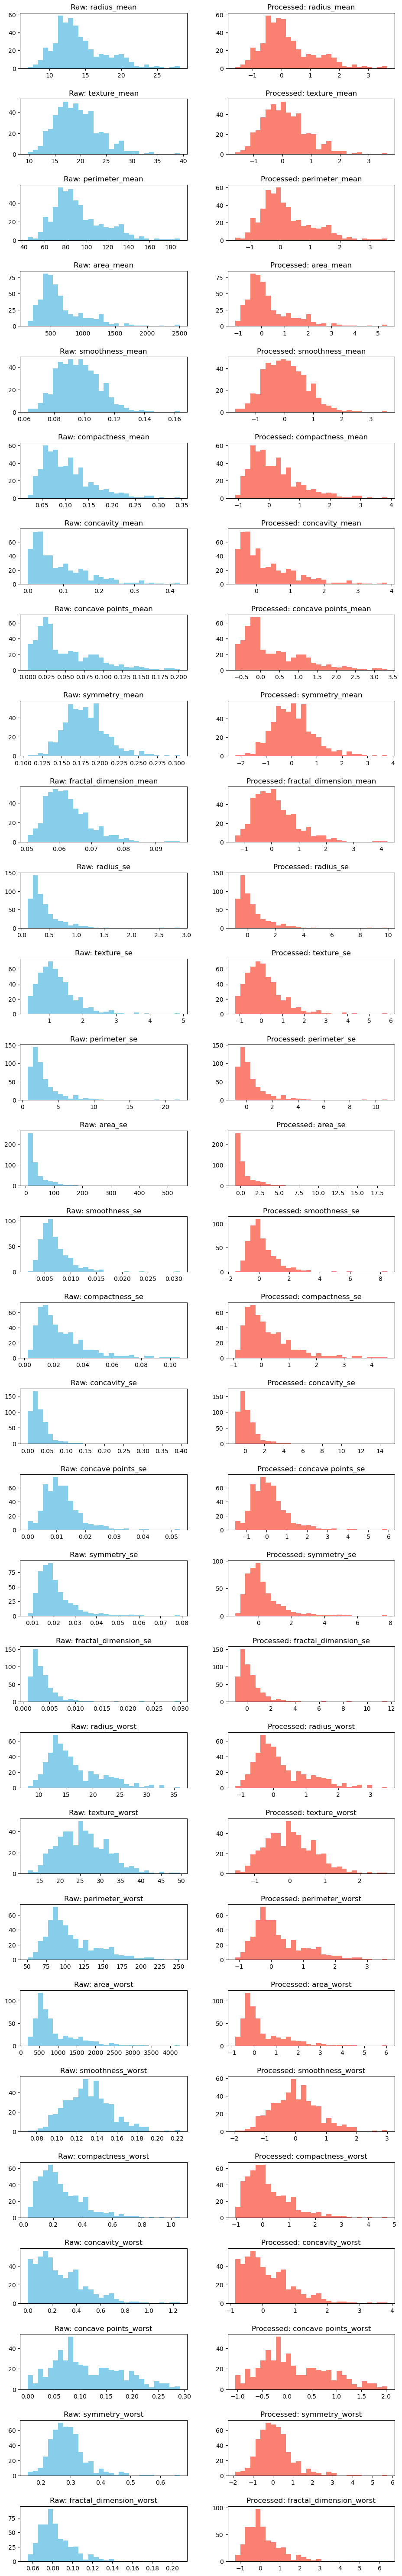

In [ ]:

feature_names = X.columns
n_cols = 2
n_rows = len(feature_names)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 2))
fig.tight_layout(pad=3.0)

for i, col in enumerate(feature_names):
    # Raw data
    axes[i, 0].hist(X[col].dropna(), bins=30, color='skyblue')
    axes[i, 0].set_title(f'Raw: {col}')
    
    # Processed data
    axes[i, 1].hist(X_prep[:, i], bins=30, color='salmon')
    axes[i, 1].set_title(f'Processed: {col}')

plt.show()


We will then plot the correlation heatmap for our features and do a Principal Component Analysis.

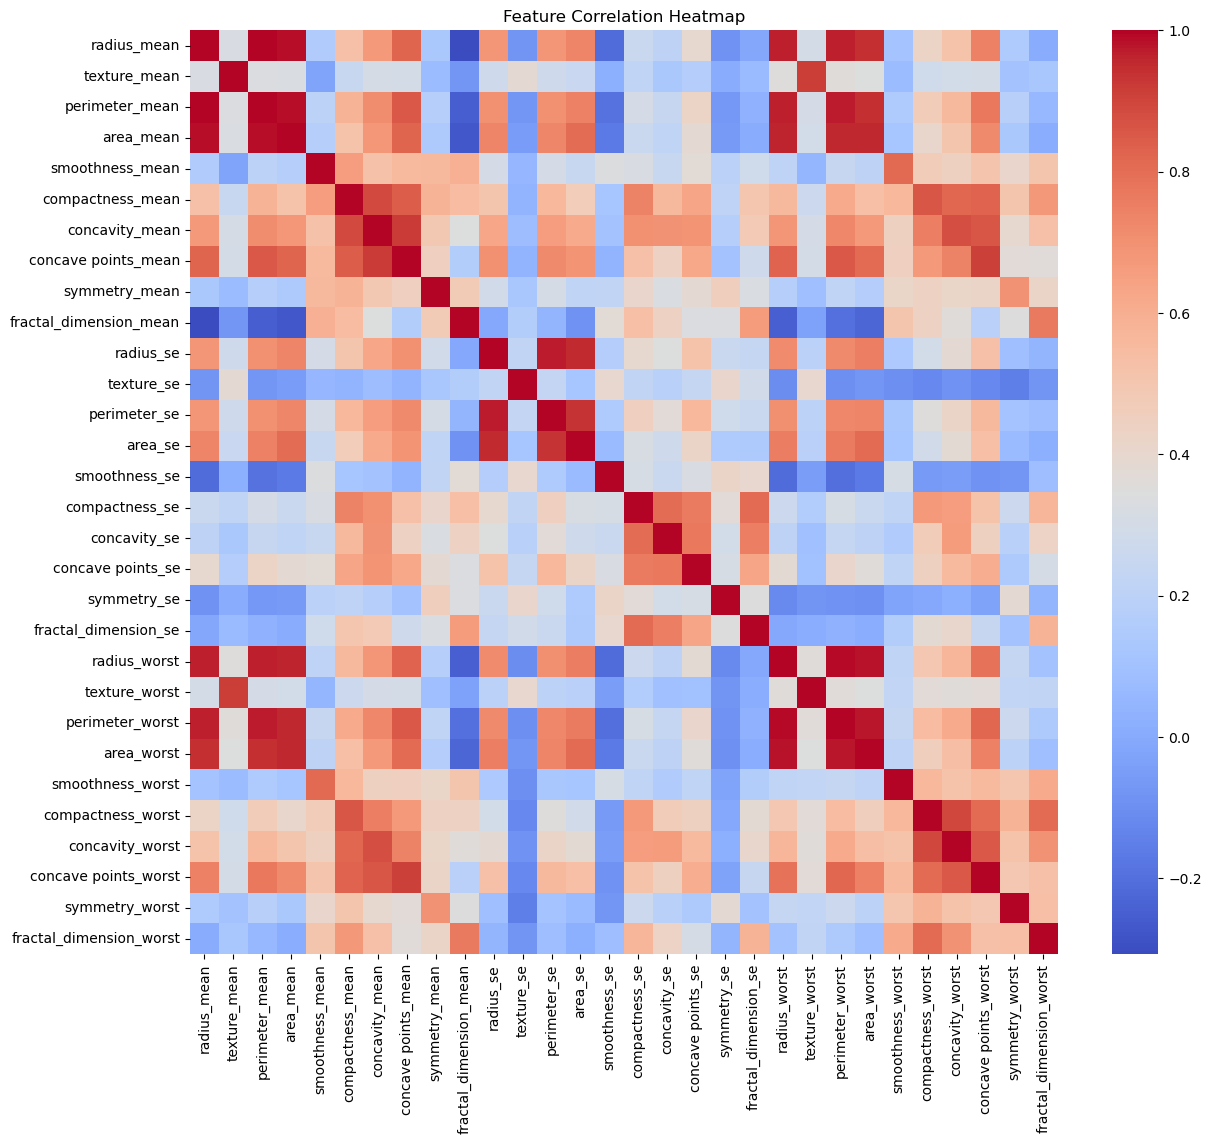

In [ ]:

plt.figure(figsize=(14, 12))
sns.heatmap(X.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


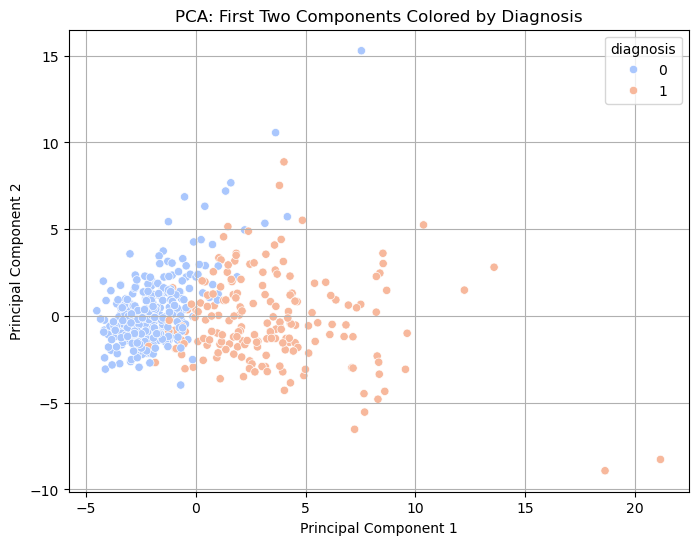

In [ ]:

# 2D PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_prep)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA: First Two Components Colored by Diagnosis")
plt.grid(True)
plt.show()


## Correlation Heatmap

Key observations:

- Correlations between `radius_mean`, `perimeter_mean`, and `area_mean`
- Many `*_worst` features correlate with their `*_mean` counterparts

### Implications

- We will retain all features initially but  **feature selection** could be good to consider later.


## Principal Component Analysis (PCA)

We applied PCA to reduce the 30-dimensional feature space to two components for visualization. The resulting 2D scatterplot shows:

- **Benign (blue)** form a tight cluster
- **Malignant (orange)** are more dispersed, reflecting biological heterogeneity


- PCA reveals **partial linear separability**: the two classes occupy overlapping, but distinguishable regions in feature space.
- The separation is not perfect, suggesting that **nonlinear classifiers** (e.g., SVM with kernels, decision trees) may outperform purely linear models.


We will proceed with training the models.